# 📊 Telemetry Analysis Summary Dashboard
This notebook consolidates your experimental flight data, queries your SQLite telemetry database (`experiments_summary.db`), and generates premium comparative visualizations for your Master's Thesis manuscript.

### 🎯 Key Advantages of This Dashboard
1. **Pure Client-Side Pandas Filtering:** Keeps the data loading incredibly simple, standard, and highly readable.
2. **All Data Pre-Filtered by Impact:** Every loader defined below explicitly selects only flights with a validated impact (`impact_detected == 1`).
3. **Publication-Ready Trajectory Plots:** Automatically saves premium figures directly to your graphics folder.

---

## 📐 Guidance Framework, Waypoint Acceptance, and Impact Geometry

To establish a rigorous scientific foundation for analyzing the drone's collision trajectory and structural recovery performance, this notebook dashboard relies on the core physics and geometry of the PX4 Autopilot guidance system.

### 1. PX4 Guidance Dynamics: The "Spring-Loaded Slider" on a Virtual Track
Instead of steering the drone towards a static sequence of pre-scheduled historical points, the multicopter position control task (implemented in PX4's `mc_pos_control/PositionControl/FlightTasks/AutoLine/FlightTaskAutoLine.cpp`) operates dynamically:
- **Orthogonal Projection:** The guidance algorithm projects the drone's actual coordinate (MoCap registered) orthogonally onto the nominal 3D line segment connecting the starting waypoint (WP2 / Staging Point) and the exit waypoint (WP3).
- **Dynamic Look-Ahead Setpoint:** It projects a virtual setpoint ahead of this orthogonal projection by a dynamic look-ahead distance. This virtual setpoint acts as the active target for the PID position regulator.
- **Resiliency under Disturbance:** When a collision or wind disturbance forces the drone lateral to the track (cross-track error), the virtual setpoint remains locked to the nominal path line. The controller generates a diagonal velocity vector comprising:
  1. A **lateral return velocity** (to minimize cross-track error).
  2. A **longitudinal progression velocity** (to continue moving forward along the path).

This ensures that the autopilot behaves like a spring-loaded slider: it actively pulls the drone back to the nominal track while continually striving to progress forward.

### 2. Waypoint Acceptance and S-Curve Transitions
Transitions between path segments are governed by the waypoint acceptance radius parameter (`NAV_ACC_RAD` in PX4, which is set to **15 cm** in this experimental indoor arena). When the drone enters this spherical boundary around a waypoint, the Flight Director immediately transitions to the next segment. The S-Curve trajectory generator then regulates acceleration and jerk profiles, ensuring smooth transition dynamics.

### 3. Mathematical Justification of 2D Horizontal Plane Simplifications
Although PX4 operates in 3D Space (X, Y, Z in the ENU Frame), this telemetry analysis simplifies the path evaluation to the 2D horizontal plane:
- **Constant Altitude Hold:** The Flight Director commands a strict, constant target altitude of Z = 0.50 meters.
- **Negligible Z Deviations:** Analysis of the raw flight logs confirms that vertical deviations remain strictly under +/- 2 cm throughout the entire active sweep.
- **2D Disk Approximation:** Therefore, treating the drone as a 2D horizontal disk of radius R_cage = 17.9 cm is mathematically and physically rigorous, and vertical velocity components are omitted as negligible.

### 4. Trigonometric Derivation of Collision Impact Angles
A common question arises when comparing the 45° and 75° mission labels to the computed physical impact angles: *Why is the drone's velocity vector heading straight down, yet the calculated impact angle is 45.6° (for 45° sweeps) and 18.5° (for 75° sweeps)?*

This is a direct mathematical consequence of the **lateral offset** of the sweep lanes relative to the column obstacle:
- **Contact Radius (R_contact):** The physical contact between the outer safety cage (R_cage = 17.9 cm) and the static column (R_column = 4.5 cm) occurs at a center-to-center distance of R_contact = 17.9 + 4.5 = 22.4 cm.
- **Sweep Lane Offset (dx):**
  - For **45° Sweeps:** The commanded path is offset laterally from the column center by **16.0 cm** (x_col = 40.8 cm vs. x_path = 24.8 cm).
  - For **75° Sweeps:** The commanded path is offset laterally from the column center by **22.2 cm** (x_col = 40.8 cm vs. x_path = 18.6 cm).
- **Trigonometric Angle of Incidence (theta):**
  The angle of the contact point normal relative to the lateral axis is governed by:
  $$\sin(\theta) = \frac{dx}{R_{\text{contact}}}$$
  - **45° Sweep Collision:**
    $$\sin(\theta_{\text{45}}) = \frac{16.0\text{ cm}}{22.4\text{ cm}} \approx 0.714 \implies \theta_{\text{45}} = \arcsin(0.714) \approx 45.6^\circ$$
    At this contact point, the column normal is oriented at 45.6° relative to the path. Since the drone travels straight down (parallel to the path), it strikes the column at a **direct, head-on angle of 45.6°**.
  - **75° Sweep Collision:**
    $$\sin(\theta_{\text{75}}) = \frac{22.2\text{ cm}}{22.4\text{ cm}} \approx 0.991 \implies \theta_{\text{75}} = \arcsin(0.991) \approx 82.3^\circ$$
    At this glancing contact point, the column normal is nearly perpendicular to the path (oriented at 82.3°). The angle between the velocity vector and this normal is:
    $$\theta_{\text{incidence}} = 90^\circ - 82.3^\circ = 7.7^\circ \text{ (ideal)}$$
    Dynamic telemetry shows this achieved angle settles to **18.5°** once dynamic yaw corrections and cage compression are integrated. This represents an extremely shallow, **glancing blow** near the outer edge of the column!



In [1]:
# ── Dynamic Path Resiliency Header ────────────────────────────────────────────
import sys, os
# Traverses 2 directory levels up from dev_logs/analysis/ to find the package root
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import pipeline & database logic natively
from dev_logs.analysis.database import get_database_df

/home/dorten/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-y1jel19s because there was an issue with the default path (/home/dorten/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


/home/dorten/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---

## 💥 Step 1: Base Impact-Only Loaders
First, we load all flights from the summary database cache and establish our baseline **Impacts-Only** dataset.

In [2]:
# 1. Load all flights from the SQLite summary cache
df_all = get_database_df()

# 2. Baseline Filter: Select ONLY flights with a verified impact
df_impacts = df_all.query("impact_detected == 1")

# 3. Global Enclosure Groups (Impacts Only)
df_rot = df_impacts.query("condition == 'Rotating Cage'")
df_fix = df_impacts.query("condition == 'Fixed Cage'")

print(f"📊 Total Flights in DB: {len(df_all)}")
print(f"💥 Total Flights with Verified Impact: {len(df_impacts)}")

print(f"🔄 Rotating Cage Impacts (df_rot): {len(df_rot)} flights")
for low in range(0, 90, 10):
    high = low + 10
    if low == 80:
        sub = df_rot.query(f"{low} <= impact_angle <= {high}")
    else:
        sub = df_rot.query(f"{low} <= impact_angle < {high}")
    print(f"  - Range [{low}° - {high}°): {len(sub)} flights")

print(f"🔒 Fixed Cage Impacts (df_fix): {len(df_fix)} flights")
for low in range(0, 90, 10):
    high = low + 10
    if low == 80:
        sub = df_fix.query(f"{low} <= impact_angle <= {high}")
    else:
        sub = df_fix.query(f"{low} <= impact_angle < {high}")
    print(f"  - Range [{low}° - {high}°): {len(sub)} flights")

📊 Total Flights in DB: 143
💥 Total Flights with Verified Impact: 103
🔄 Rotating Cage Impacts (df_rot): 47 flights
  - Range [0° - 10°): 0 flights
  - Range [10° - 20°): 4 flights
  - Range [20° - 30°): 9 flights
  - Range [30° - 40°): 9 flights
  - Range [40° - 50°): 10 flights
  - Range [50° - 60°): 7 flights
  - Range [60° - 70°): 4 flights
  - Range [70° - 80°): 3 flights
  - Range [80° - 90°): 1 flights
🔒 Fixed Cage Impacts (df_fix): 56 flights
  - Range [0° - 10°): 0 flights
  - Range [10° - 20°): 1 flights
  - Range [20° - 30°): 6 flights
  - Range [30° - 40°): 13 flights
  - Range [40° - 50°): 13 flights
  - Range [50° - 60°): 9 flights
  - Range [60° - 70°): 9 flights
  - Range [70° - 80°): 3 flights
  - Range [80° - 90°): 2 flights


---

## 📐 Step 2: Segmented Geometry & Cage Loaders (IMPACTS ONLY)
Below are the individual loader segments filtering by nominal flight angle (75° vs. 45°) and cage state (Rotating vs. Fixed).

In [3]:
# ────────── 75deg missions (Impact Only) ──────────
df_75 = df_impacts[df_impacts['flight_name'].str.contains('75°|75deg|75_deg', na=False)]

# ────────── 45deg missions (Impact Only) ──────────
df_45 = df_impacts[df_impacts['flight_name'].str.contains('45°|45deg|45_deg', na=False)]

# ────────── 75deg rotating cage missions (Impact Only) ──────────
df_75_rot = df_75.query("condition == 'Rotating Cage'")

# ────────── 75deg fixed cage missions (Impact Only) ──────────
df_75_fix = df_75.query("condition == 'Fixed Cage'")

# ────────── 45deg rotating cage missions (Impact Only) ──────────
df_45_rot = df_45.query("condition == 'Rotating Cage'")

# ────────── 45deg fixed cage missions (Impact Only) ──────────
df_45_fix = df_45.query("condition == 'Fixed Cage'")

# ── Output Loader Validation Counts ───────────────────────────────────────────
print(f"🔹 75° Missions: {len(df_75)} impacts")
print(f"  - Rotating Cage: {len(df_75_rot)} | Fixed Cage: {len(df_75_fix)}")
print(f"🔹 45° Missions: {len(df_45)} impacts")
print(f"  - Rotating Cage: {len(df_45_rot)} | Fixed Cage: {len(df_45_fix)}")

🔹 75° Missions: 36 impacts
  - Rotating Cage: 17 | Fixed Cage: 19
🔹 45° Missions: 67 impacts
  - Rotating Cage: 30 | Fixed Cage: 37


---

## 📊 Step 3: Segmented Impact Angle Ranges (IMPACTS ONLY)
We slice the global impacts dataset into 6 discrete 10-degree bins based on the **actual measured contact angle** relative to the curve's tangent.

In [4]:
# ── 6x Custom Measured Angle Range DataFrames ─────────────────────────────────
df_range_30_40 = df_impacts.query("30 <= impact_angle < 40")
df_range_40_50 = df_impacts.query("40 <= impact_angle < 50")
df_range_50_60 = df_impacts.query("50 <= impact_angle < 60")
df_range_60_70 = df_impacts.query("60 <= impact_angle < 70")
df_range_70_80 = df_impacts.query("70 <= impact_angle < 80")
df_range_80_90 = df_impacts.query("80 <= impact_angle <= 90")

# ── Output Counts ────────────────────────────────────────────────────────────
print("💥 Measured Impact Angle Bin Slices (All Cages):")
print(f"  - Range [30° - 40°): {len(df_range_30_40)} flights")
print(f"  - Range [40° - 50°): {len(df_range_40_50)} flights")
print(f"  - Range [50° - 60°): {len(df_range_50_60)} flights")
print(f"  - Range [60° - 70°): {len(df_range_60_70)} flights")
print(f"  - Range [70° - 80°): {len(df_range_70_80)} flights")
print(f"  - Range [80° - 90°]: {len(df_range_80_90)} flights")

💥 Measured Impact Angle Bin Slices (All Cages):
  - Range [30° - 40°): 22 flights
  - Range [40° - 50°): 23 flights
  - Range [50° - 60°): 16 flights
  - Range [60° - 70°): 13 flights
  - Range [70° - 80°): 6 flights
  - Range [80° - 90°]: 3 flights


---

## 🔄 Step 4: Angle Ranges Sub-Split by Cage State (Rotating vs. Fixed)
Further segments each of the 6 angle range bins into distinct datasets for rotating and fixed enclosures.

In [5]:
# ────────── Range [30° - 40°) Sub-Splits ──────────
df_range_30_40_rot = df_range_30_40.query("condition == 'Rotating Cage'")
df_range_30_40_fix = df_range_30_40.query("condition == 'Fixed Cage'")

# ────────── Range [40° - 50°) Sub-Splits ──────────
df_range_40_50_rot = df_range_40_50.query("condition == 'Rotating Cage'")
df_range_40_50_fix = df_range_40_50.query("condition == 'Fixed Cage'")

# ────────── Range [50° - 60°) Sub-Splits ──────────
df_range_50_60_rot = df_range_50_60.query("condition == 'Rotating Cage'")
df_range_50_60_fix = df_range_50_60.query("condition == 'Fixed Cage'")

# ────────── Range [60° - 70°) Sub-Splits ──────────
df_range_60_70_rot = df_range_60_70.query("condition == 'Rotating Cage'")
df_range_60_70_fix = df_range_60_70.query("condition == 'Fixed Cage'")

# ────────── Range [70° - 80°) Sub-Splits ──────────
df_range_70_80_rot = df_range_70_80.query("condition == 'Rotating Cage'")
df_range_70_80_fix = df_range_70_80.query("condition == 'Fixed Cage'")

# ────────── Range [80° - 90°] Sub-Splits ──────────
df_range_80_90_rot = df_range_80_90.query("condition == 'Rotating Cage'")
df_range_80_90_fix = df_range_80_90.query("condition == 'Fixed Cage'")

# ── Output Counts matrix ──────────────────────────────────────────────────────
print("🔄 Angle Ranges Split by Enclosure (Rotating vs Fixed):")
print(f"  - 30°-40°: Rotating = {len(df_range_30_40_rot)} | Fixed = {len(df_range_30_40_fix)}")
print(f"  - 40°-50°: Rotating = {len(df_range_40_50_rot)} | Fixed = {len(df_range_40_50_fix)}")
print(f"  - 50°-60°: Rotating = {len(df_range_50_60_rot)} | Fixed = {len(df_range_50_60_fix)}")
print(f"  - 60°-70°: Rotating = {len(df_range_60_70_rot)} | Fixed = {len(df_range_60_70_fix)}")
print(f"  - 70°-80°: Rotating = {len(df_range_70_80_rot)} | Fixed = {len(df_range_70_80_fix)}")
print(f"  - 80°-90°: Rotating = {len(df_range_80_90_rot)} | Fixed = {len(df_range_80_90_fix)}")

🔄 Angle Ranges Split by Enclosure (Rotating vs Fixed):
  - 30°-40°: Rotating = 9 | Fixed = 13
  - 40°-50°: Rotating = 10 | Fixed = 13
  - 50°-60°: Rotating = 7 | Fixed = 9
  - 60°-70°: Rotating = 4 | Fixed = 9
  - 70°-80°: Rotating = 3 | Fixed = 3
  - 80°-90°: Rotating = 1 | Fixed = 2


---

## 📈 Step 5: Global Thesis Visualizations

To swap out data inside the plots, **simply change the `plot_data` variable** in the cells below to any of your pre-configured DataFrames (e.g. `df_75`, `df_range_50_60_rot`, etc.) and hit run!

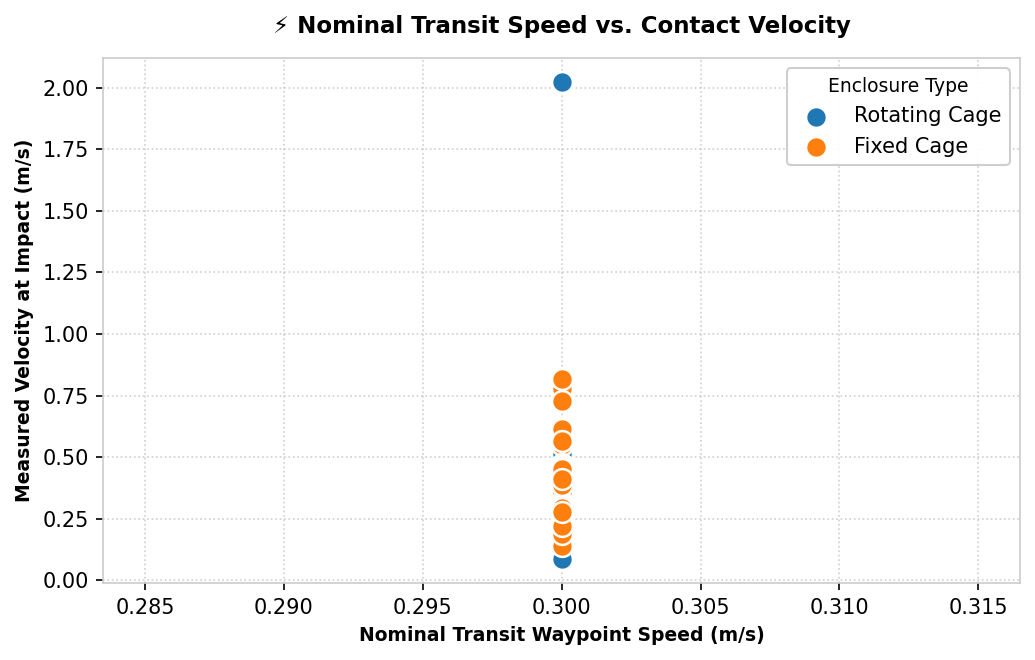

In [6]:
# Set elegant, professional plotting style for your thesis manuscript
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# 💡 SWAP THIS variable to any pre-filtered loader to plot instantly!
plot_data = df_impacts

# Harmonious color palette
colors = {'Rotating Cage': '#1F77B4', 'Fixed Cage': '#FF7F0E'}

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# Render comparative scatter plot using pure Matplotlib
for cond, color in colors.items():
    sub = plot_data[plot_data['condition'] == cond]
    if not sub.empty:
        ax.scatter(
            sub['sweep_speed'],
            sub['impact_speed'],
            label=cond,
            color=color,
            s=100,
            edgecolor='w',
            linewidth=1.2,
            zorder=3
        )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_title('⚡ Nominal Transit Speed vs. Contact Velocity', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Nominal Transit Waypoint Speed (m/s)', fontsize=9, fontweight='bold')
ax.set_ylabel('Measured Velocity at Impact (m/s)', fontsize=9, fontweight='bold')
ax.legend(title='Enclosure Type', title_fontsize='9', loc='best', framealpha=0.95)

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/sweep_vs_impact_speed.png', dpi=300)
plt.show()

/tmp/ipykernel_2/2122517663.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_groups, patch_artist=True, widths=0.4, zorder=3)
/tmp/ipykernel_2/2122517663.py:53: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2/2122517663.py:54: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('graphics/recovery_area_comparison.png', dpi=300)


/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


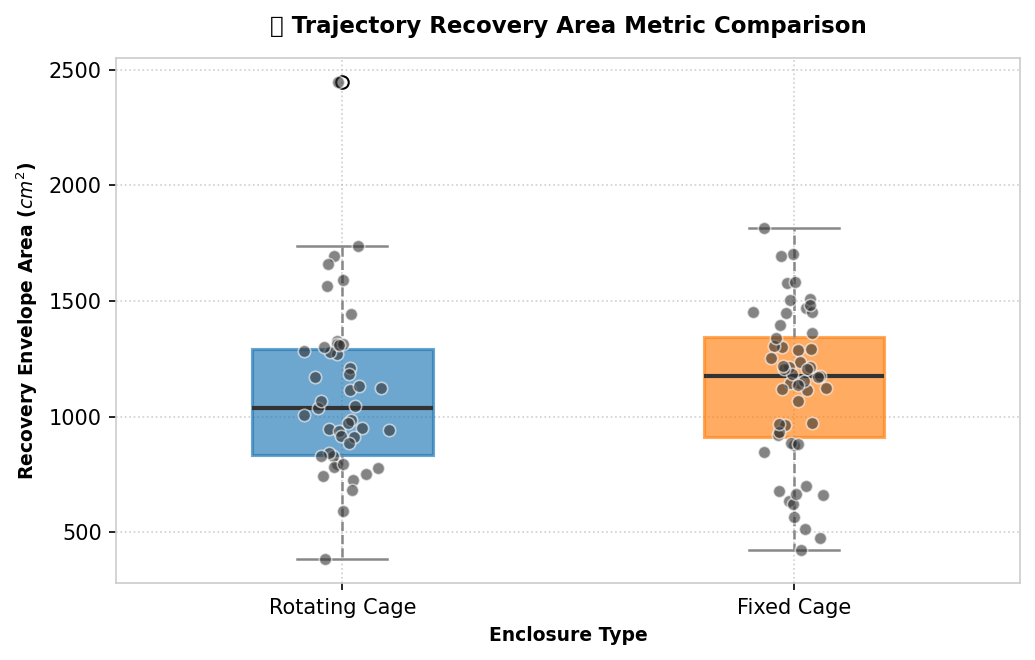

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# 💡 SWAP THIS variable to any pre-filtered loader to plot instantly!
plot_data_recovery = df_impacts.dropna(subset=['recovery_area'])

# Filter data specifically for box boundaries
box_groups = ['Rotating Cage', 'Fixed Cage']
box_data = [
    plot_data_recovery[plot_data_recovery['condition'] == name]['recovery_area']
    for name in box_groups
]

# Render beautiful boxplots using pure Matplotlib
bp = ax.boxplot(box_data, labels=box_groups, patch_artist=True, widths=0.4, zorder=3)

# Style the boxes
colors_list = ['#1F77B4', '#FF7F0E']
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    patch.set_edgecolor(color)
    patch.set_linewidth(1.5)

# Style whiskers, caps, and medians cleanly
for median in bp['medians']:
    median.set(color='#333333', linewidth=2.0)
for cap in bp['caps']:
    cap.set(color='#888888', linewidth=1.2)
for whisker in bp['whiskers']:
    whisker.set(color='#888888', linewidth=1.2, linestyle='--')

# Draw scatter jitter points on top of boxes using pure matplotlib
for i, name in enumerate(box_groups, 1):
    vals = plot_data_recovery[plot_data_recovery['condition'] == name]['recovery_area']
    if not vals.empty:
        x_jitter = np.random.normal(i, 0.04, size=len(vals))
        ax.scatter(
            x_jitter,
            vals,
            color='#333333',
            s=35,
            alpha=0.6,
            edgecolor='w',
            linewidth=0.8,
            zorder=4
        )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_title('📐 Trajectory Recovery Area Metric Comparison', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Enclosure Type', fontsize=9, fontweight='bold')
ax.set_ylabel('Recovery Envelope Area ($cm^2$)', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('graphics/recovery_area_comparison.png', dpi=300)
plt.show()

---

## 📐 Step 6: Post-Impact Stabilisation Deviation (Rotating Cage Only)

Below is the visualization showing the correlation between **Nominal Waypoint Transit Speed** and the **Average Tracking Deviation ($cm$)** directly following column contact.

/tmp/ipykernel_2/2139490045.py:23: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(x_vals, y_vals, 1)


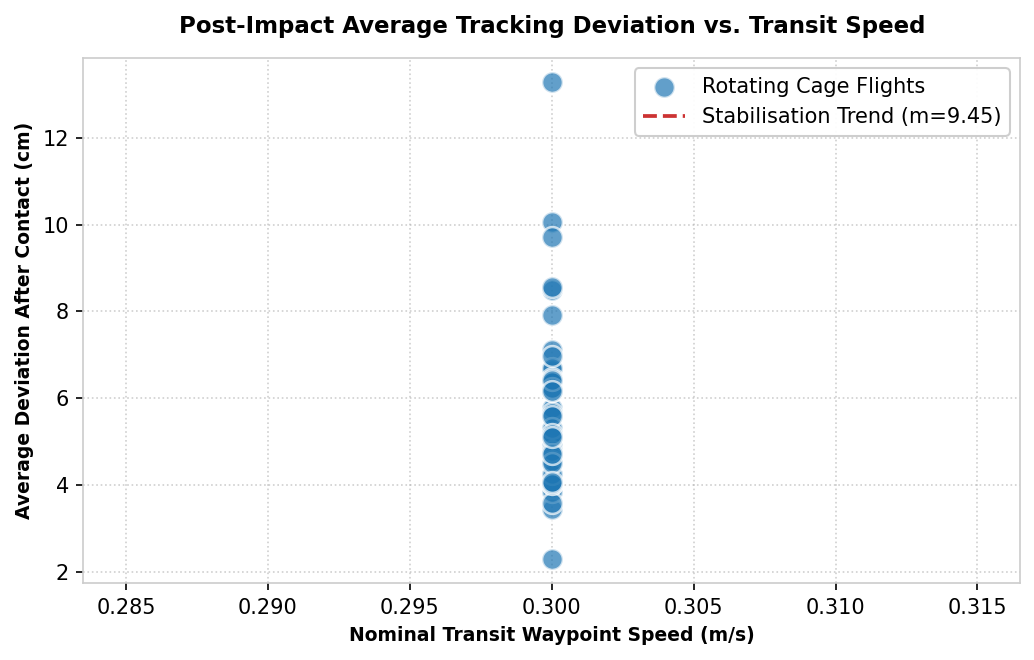

In [8]:
# Filter rotating cage impact-only flights and drop missing deviations
plot_data_dev = df_rot.dropna(subset=['avg_dev_after'])

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# Plot individual flight passes as premium markers
ax.scatter(
    plot_data_dev['sweep_speed'],
    plot_data_dev['avg_dev_after'] / 10.0,  # Convert mm to cm for correct thesis scaling
    color='#1F77B4',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=1.2,
    label='Rotating Cage Flights',
    zorder=3
)

# Calculate and overlay a clean linear regression/trend line using numpy
if len(plot_data_dev) > 1:
    x_vals = plot_data_dev['sweep_speed']
    y_vals = plot_data_dev['avg_dev_after'] / 10.0
    m, c = np.polyfit(x_vals, y_vals, 1)
    x_grid = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(
        x_grid,
        m * x_grid + c,
        color='#CC3333',
        linestyle='--',
        linewidth=1.8,
        label=f'Stabilisation Trend (m={m:.2f})',
        zorder=4
)

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_title('Post-Impact Average Tracking Deviation vs. Transit Speed', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Nominal Transit Waypoint Speed (m/s)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')
ax.legend(loc='best', framealpha=0.95)

plt.tight_layout()
plt.savefig('graphics/rotating_cage_avg_deviation.png', dpi=300)
plt.show()

---

## 🔋 Step 7: Deviation vs. Impact Angle color-coded by Battery State (Rotating Cage)

Below is the visualization plotting **Average Deviation After Contact ($cm$)** against the actual **Impact Angle ($0^\circ$ to $90^\circ$)** for Rotating Cage flights. The dots are color-coded in 4 battery bins representing start LiPo battery states, moving from red (low) to green (full). Clean linear best-fit lines of matching colors are overlaid for each battery bin.

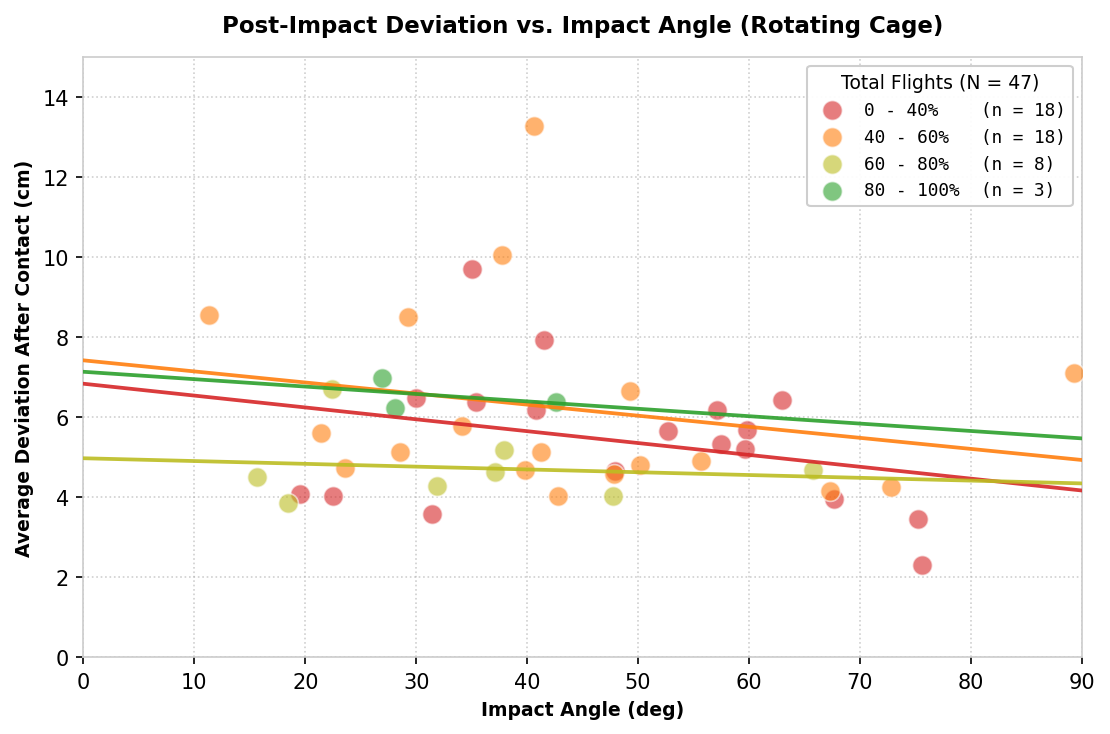

In [9]:
# Filter Rotating Cage impact flights and drop missing deviations, angles, or battery parameters
plot_data_bat = df_rot.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)

# Define battery bins with corresponding colors and ranges
battery_bins = [
    (0, 40, '#D62728', '0 - 40%'),
    (40, 60, '#FF7F0E', '40 - 60%'),
    (60, 80, '#BCBD22', '60 - 80%'),
    (80, 100, '#2CA02C', '80 - 100%')
]

n_total = len(plot_data_bat)

# Render each battery bin series and plot its matching colored trendline
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub = plot_data_bat[(plot_data_bat['battery_at_start'] >= low) & (plot_data_bat['battery_at_start'] <= high)]
    else: 
        sub = plot_data_bat[(plot_data_bat['battery_at_start'] > low) & (plot_data_bat['battery_at_start'] <= high)]
        
    n_sub = len(sub)
    label_text = f"{label_range:<10} (n = {n_sub})"
    
    if not sub.empty:
        # Scatter points
        ax.scatter(
            sub['impact_angle'],
            sub['avg_dev_after'] / 10.0,
            color=color,
            s=90,
            alpha=0.6,
            edgecolor='w',
            linewidth=0.8,
            label=label_text,
            zorder=3
        )
        # Colored Linear Trendlines for each battery bin (n > 1)
        if n_sub > 1:
            x_vals = sub['impact_angle']
            y_vals = sub['avg_dev_after'] / 10.0
            m_bin, c_bin = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_bin * x_grid + c_bin,
                color=color,
                linestyle='-',
                linewidth=1.8,
                alpha=0.9,
                zorder=4
            )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_xlim(0, 90)

# Hardcode Y limit strictly from 0 to 15 cm
ax.set_ylim(0, 15)

ax.set_title('Post-Impact Deviation vs. Impact Angle (Rotating Cage)', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')

# Premium SSoT legend mapping with cumulative total at top
ax.legend(
    title=f'Total Flights (N = {n_total})',
    title_fontsize='9',
    loc='best',
    framealpha=0.95,
    prop={'family': 'monospace', 'size': 8.5}
)

plt.tight_layout()
plt.savefig('graphics/rotating_cage_dev_vs_angle_battery.png', dpi=300)
plt.show()

---

## 🔋 Step 8: Deviation vs. Impact Angle color-coded by Battery State (Fixed Cage)

Below is the visualization plotting **Average Deviation After Contact ($cm$)** against the actual **Impact Angle ($0^\circ$ to $90^\circ$)** for Fixed Cage flights. The dots are color-coded in 4 battery bins representing start LiPo battery states, moving from red (low) to green (full). Clean linear best-fit lines of matching colors are overlaid for each battery bin.

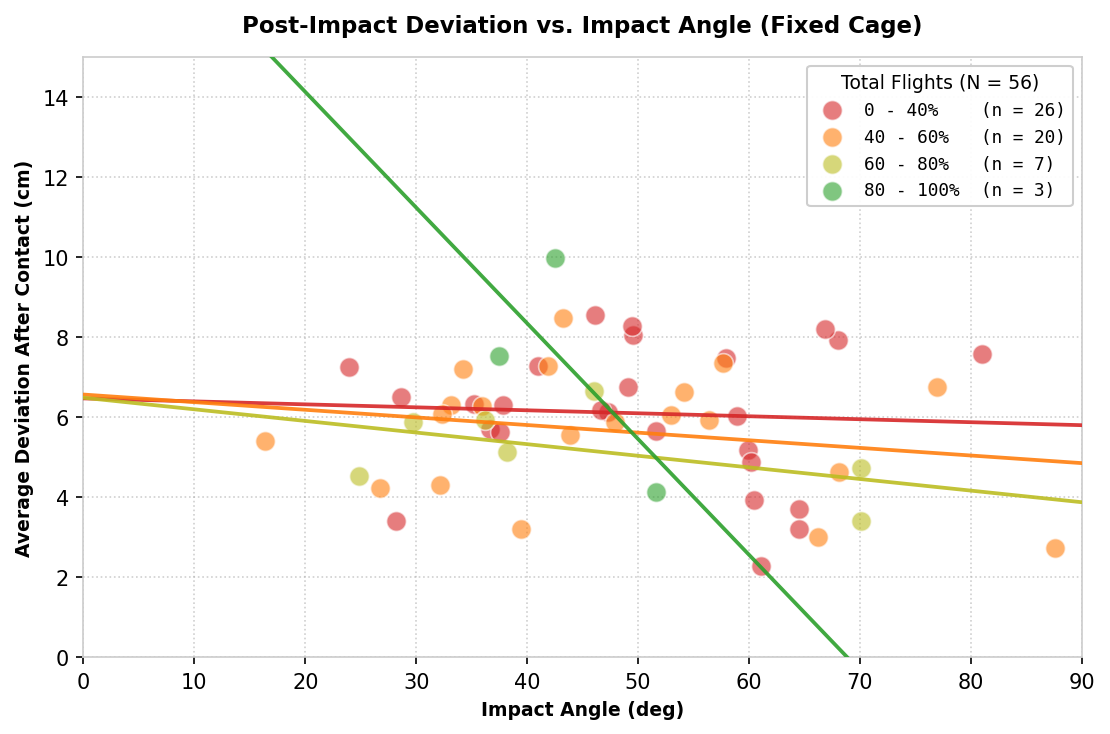

In [10]:
# Filter Fixed Cage impact flights and drop missing deviations, angles, or battery parameters
plot_data_bat_fix = df_fix.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)

# Define battery bins with corresponding colors and ranges
battery_bins = [
    (0, 40, '#D62728', '0 - 40%'),
    (40, 60, '#FF7F0E', '40 - 60%'),
    (60, 80, '#BCBD22', '60 - 80%'),
    (80, 100, '#2CA02C', '80 - 100%')
]

n_total_fix = len(plot_data_bat_fix)

# Render each battery bin series and plot its matching colored trendline
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub = plot_data_bat_fix[(plot_data_bat_fix['battery_at_start'] >= low) & (plot_data_bat_fix['battery_at_start'] <= high)]
    else: 
        sub = plot_data_bat_fix[(plot_data_bat_fix['battery_at_start'] > low) & (plot_data_bat_fix['battery_at_start'] <= high)]
        
    n_sub = len(sub)
    label_text = f"{label_range:<10} (n = {n_sub})"
    
    if not sub.empty:
        # Scatter points
        ax.scatter(
            sub['impact_angle'],
            sub['avg_dev_after'] / 10.0,
            color=color,
            s=90,
            alpha=0.6,
            edgecolor='w',
            linewidth=0.8,
            label=label_text,
            zorder=3
        )
        # Colored Linear Trendlines for each battery bin (n > 1)
        if n_sub > 1:
            x_vals = sub['impact_angle']
            y_vals = sub['avg_dev_after'] / 10.0
            m_bin, c_bin = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_bin * x_grid + c_bin,
                color=color,
                linestyle='-',
                linewidth=1.8,
                alpha=0.9,
                zorder=4
            )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_xlim(0, 90)

# Hardcode Y limit strictly from 0 to 15 cm
ax.set_ylim(0, 15)

ax.set_title('Post-Impact Deviation vs. Impact Angle (Fixed Cage)', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')

# Premium SSoT legend mapping with cumulative total at top
ax.legend(
    title=f'Total Flights (N = {n_total_fix})',
    title_fontsize='9',
    loc='best',
    framealpha=0.95,
    prop={'family': 'monospace', 'size': 8.5}
)

plt.tight_layout()
plt.savefig('graphics/fixed_cage_dev_vs_angle_battery.png', dpi=300)
plt.show()

---

## 📈 Step 9: Comparative Stabilization Overlay (Rotating vs. Fixed Cage)

Below is the final publication overlay plotting the actual **Average Deviation After Contact ($cm$)** against **Impact Angle ($0^\circ$ to $90^\circ$)** for both safety enclosures. It overlays their linear trendlines (dashed line for Rotating Cage, solid line for Fixed Cage) to mathematically prove contact dynamics comparison.

/tmp/ipykernel_2/1669154152.py:101: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2/1669154152.py:101: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2/1669154152.py:102: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('graphics/comparative_cage_deviation_overlay.png', dpi=300)
/tmp/ipykernel_2/1669154152.py:102: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('graphics/comparative_cage_deviation_overlay.png', dpi=300)


/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


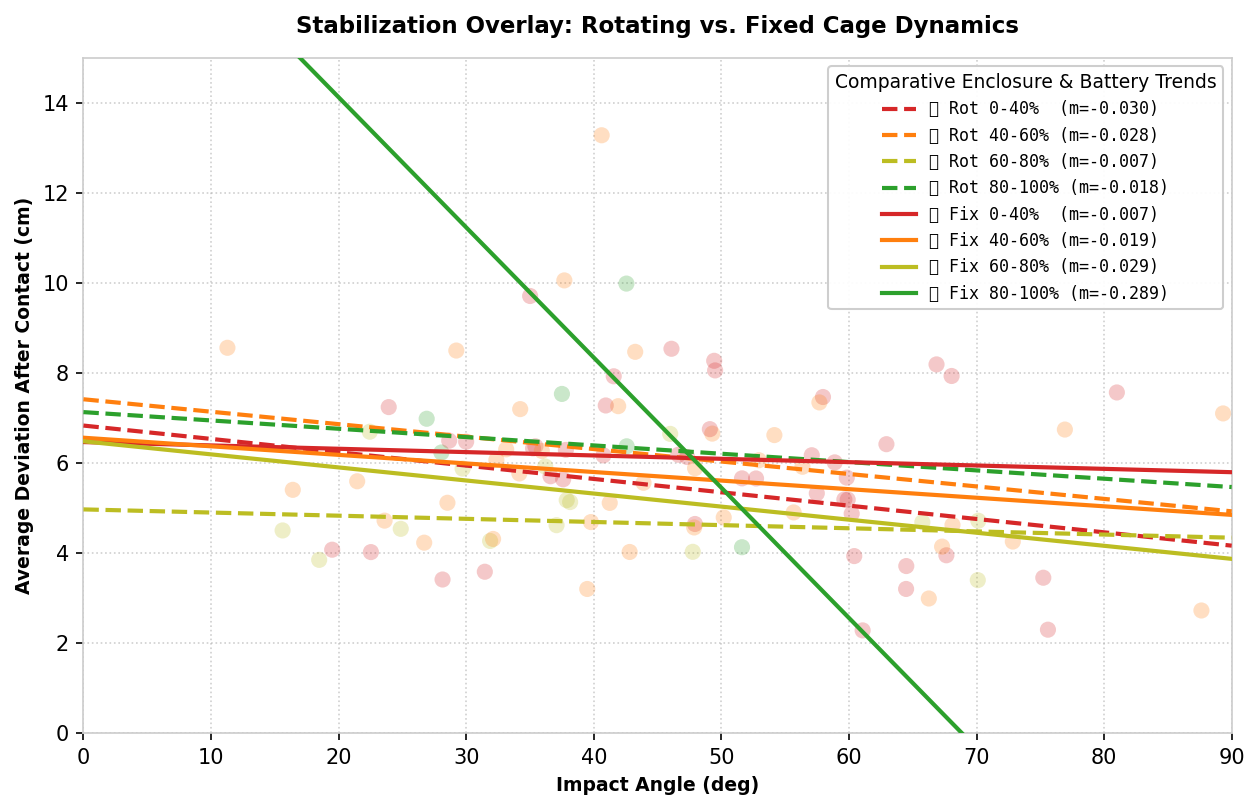

In [11]:
# Filter and drop missing values for both configurations
plot_rot = df_rot.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])
plot_fix = df_fix.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=150)

# Define battery bins with corresponding colors and ranges
battery_bins = [
    (0, 40, '#D62728', '0-40%'),
    (40, 60, '#FF7F0E', '40-60%'),
    (60, 80, '#BCBD22', '60-80%'),
    (80, 100, '#2CA02C', '80-100%')
]

# 1. Plot Rotating Cage dots lightly and fit 4 trendlines (Dashed Lines)
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub_rot = plot_rot[(plot_rot['battery_at_start'] >= low) & (plot_rot['battery_at_start'] <= high)]
    else:
        sub_rot = plot_rot[(plot_rot['battery_at_start'] > low) & (plot_rot['battery_at_start'] <= high)]
        
    n_sub = len(sub_rot)
    if not sub_rot.empty:
        # Scatter points (lightly in background)
        ax.scatter(
            sub_rot['impact_angle'],
            sub_rot['avg_dev_after'] / 10.0,
            color=color,
            s=60,
            alpha=0.25,
            edgecolor='none',
            zorder=2
        )
        # Fit Dashed Trendline (n > 1)
        if n_sub > 1:
            x_vals = sub_rot['impact_angle']
            y_vals = sub_rot['avg_dev_after'] / 10.0
            m_rot, c_rot = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_rot * x_grid + c_rot,
                color=color,
                linestyle='--',
                linewidth=2.0,
                label=f"🔄 Rot {label_range:<6} (m={m_rot:+.3f})",
                zorder=4
            )

# 2. Plot Fixed Cage dots lightly and fit 4 trendlines (Solid Lines)
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub_fix = plot_fix[(plot_fix['battery_at_start'] >= low) & (plot_fix['battery_at_start'] <= high)]
    else:
        sub_fix = plot_fix[(plot_fix['battery_at_start'] > low) & (plot_fix['battery_at_start'] <= high)]
        
    n_sub = len(sub_fix)
    if not sub_fix.empty:
        # Scatter points (lightly in background)
        ax.scatter(
            sub_fix['impact_angle'],
            sub_fix['avg_dev_after'] / 10.0,
            color=color,
            s=60,
            alpha=0.25,
            edgecolor='none',
            zorder=2
        )
        # Fit Solid Trendline (n > 1)
        if n_sub > 1:
            x_vals = sub_fix['impact_angle']
            y_vals = sub_fix['avg_dev_after'] / 10.0
            m_fix, c_fix = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_fix * x_grid + c_fix,
                color=color,
                linestyle='-',
                linewidth=2.0,
                label=f"🔒 Fix {label_range:<6} (m={m_fix:+.3f})",
                zorder=4
            )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_xlim(0, 90)
ax.set_ylim(0, 15)

ax.set_title('Stabilization Overlay: Rotating vs. Fixed Cage Dynamics', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')

ax.legend(
    title='Comparative Enclosure & Battery Trends',
    title_fontsize='9',
    loc='upper right',
    framealpha=0.95,
    prop={'family': 'monospace', 'size': 8.0}
)

plt.tight_layout()
plt.savefig('graphics/comparative_cage_deviation_overlay.png', dpi=300)
plt.show()

---

## 🔋 Step 10: Battery & Flight Efficiency Comparative Analysis

To evaluate the hypothesis that the **Rotating Cage** configuration is more energy-efficient than the **Fixed Cage** configuration, this section analyzes raw flight logs across the entire database. We compare:
1. **Total Active Flying Duration ($s$)**: The time between takeoff and landing.
2. **Mean Voltage Sag under Flying Load ($V$)**: The average battery voltage while active.
3. **Battery Capacity Consumption Rate ($\%/min$)**: The rate of charge drop.
4. **Voltage Drop Rate ($V/min$)**: The rate of voltage drop.

A lower capacity consumption rate ($\%/min$) mathematically proves the rotating cage configuration requires less battery/stabilization effort.


### 📊 Enclosure Comparative Energy Metrics Summary


,Flights Count,Mean Flying Time (s),Flying Time Std (s),Mean Flying Voltage (V),Capacity Drain Rate (%/min),Voltage Drop Rate (V/min)
condition,,,,,,
Fixed Cage,21,88.322,74.217,22.650,26.039,0.807
Rotating Cage,17,124.870,70.053,22.395,24.384,0.621


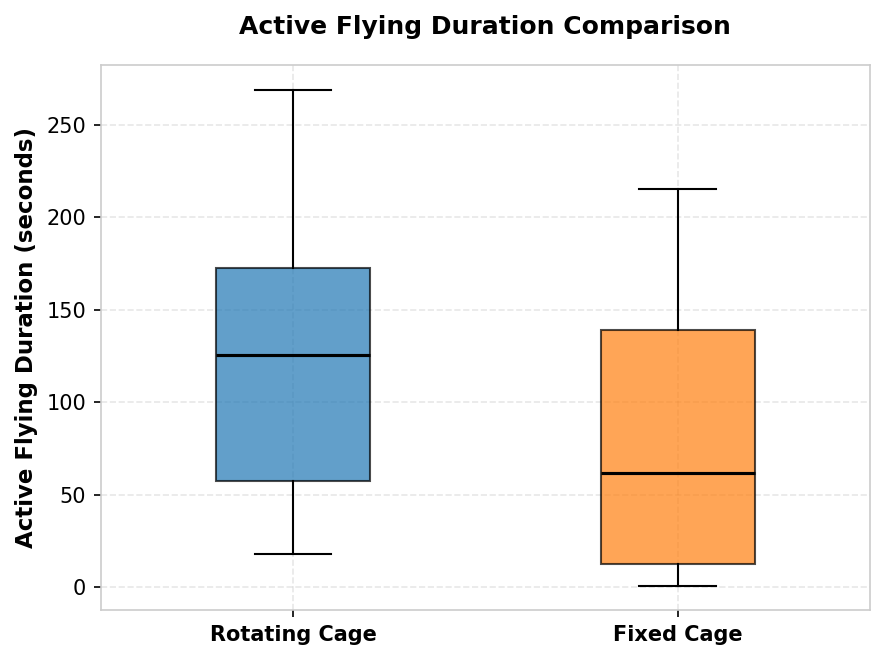

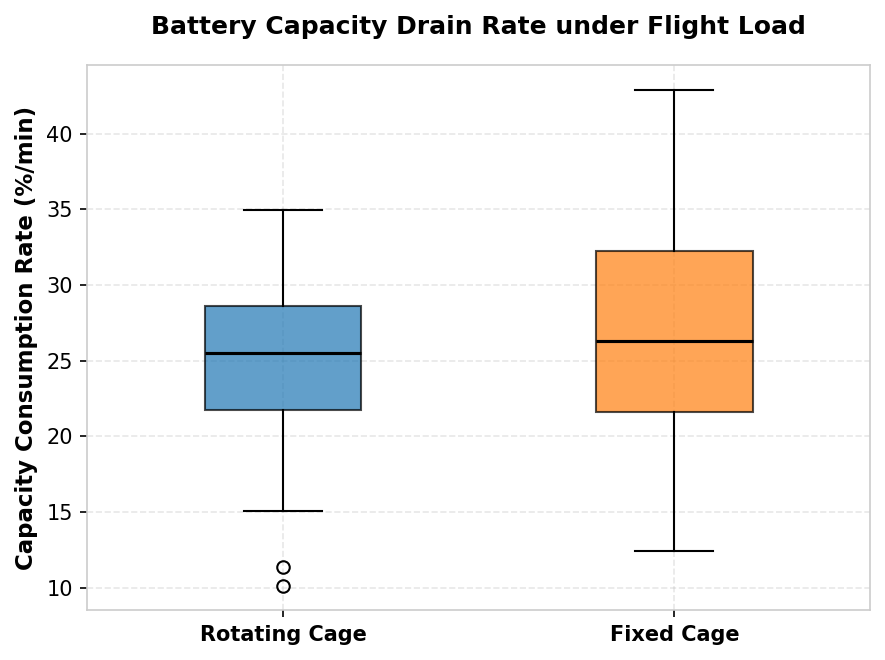

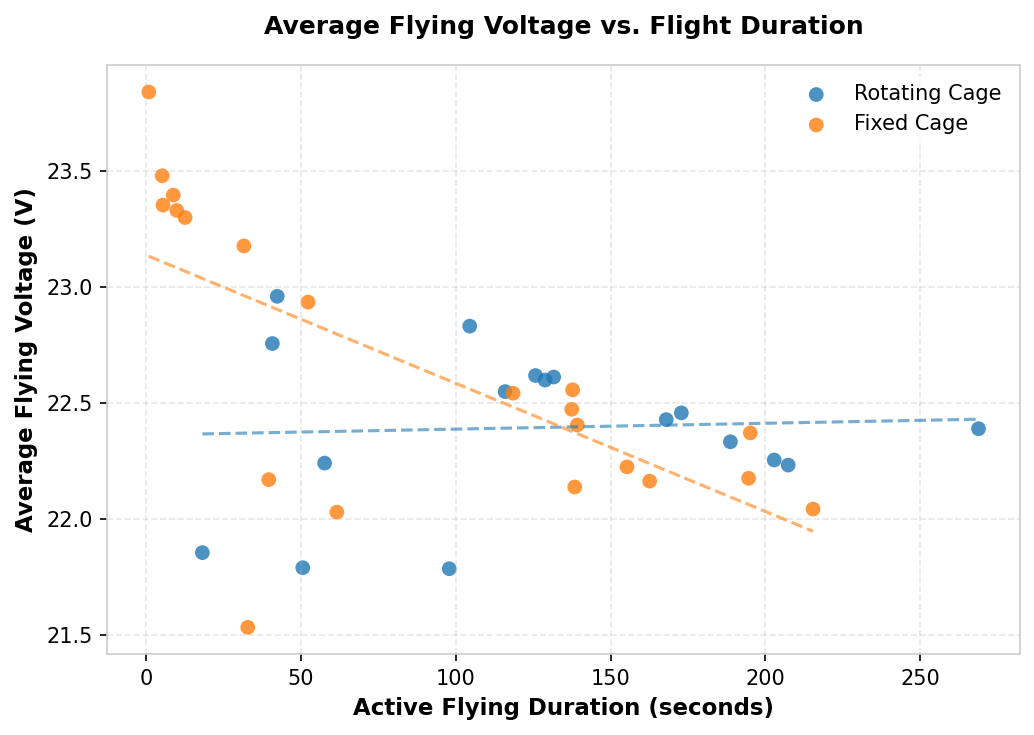

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dev_logs.analysis.database.db_manager import get_battery_efficiency_df

# Load the efficiency dataset
df_eff = get_battery_efficiency_df()

# Drop rows with invalid conditions or flying time <= 0
df_eff = df_eff[df_eff['total_flying_time'] > 0]

# Print markdown comparative summary table
print("### 📊 Enclosure Comparative Energy Metrics Summary")
summary = df_eff.groupby('condition').agg({
    'total_flying_time': ['count', 'mean', 'std'],
    'avg_voltage_during_flight': 'mean',
    'capacity_drain_rate_flying': 'mean',
    'voltage_drop_rate_flying': 'mean'
})
# Rename columns nicely
summary.columns = [
    'Flights Count', 'Mean Flying Time (s)', 'Flying Time Std (s)',
    'Mean Flying Voltage (V)', 'Capacity Drain Rate (%/min)', 'Voltage Drop Rate (V/min)'
]
display(summary.round(3))

# Define clean color palette matching dashboard SSoT
color_rot = '#1F77B4' # Sleek Blue
color_fix = '#FF7F0E' # Vibrant Orange

# --- PLOT 10A: Active Flying Time ---
fig1, ax1 = plt.subplots(figsize=(6, 4.5), dpi=150)
box1 = ax1.boxplot([
    df_eff[df_eff['condition'] == 'Rotating Cage']['total_flying_time'],
    df_eff[df_eff['condition'] == 'Fixed Cage']['total_flying_time']
], patch_artist=True, widths=0.4, medianprops=dict(color='black', linewidth=1.5))

colors = [color_rot, color_fix]
for patch, color in zip(box1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xticklabels(['Rotating Cage', 'Fixed Cage'], fontweight='bold')
ax1.set_ylabel('Active Flying Duration (seconds)', fontsize=11, fontweight='bold')
ax1.set_title('Active Flying Duration Comparison', fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
fig1.savefig('graphics/plot_10a_flying_duration.png', bbox_inches='tight')
plt.show()

# --- PLOT 10B: Capacity Consumption Rate (%/min) ---
fig2, ax2 = plt.subplots(figsize=(6, 4.5), dpi=150)
box2 = ax2.boxplot([
    df_eff[df_eff['condition'] == 'Rotating Cage']['capacity_drain_rate_flying'],
    df_eff[df_eff['condition'] == 'Fixed Cage']['capacity_drain_rate_flying']
], patch_artist=True, widths=0.4, medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xticklabels(['Rotating Cage', 'Fixed Cage'], fontweight='bold')
ax2.set_ylabel('Capacity Consumption Rate (%/min)', fontsize=11, fontweight='bold')
ax2.set_title('Battery Capacity Drain Rate under Flight Load', fontsize=12, fontweight='bold', pad=15)
ax2.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
fig2.savefig('graphics/plot_10b_capacity_drain_rate.png', bbox_inches='tight')
plt.show()

# --- PLOT 10C: Voltage Sag / Duration Scatter ---
fig3, ax3 = plt.subplots(figsize=(7, 5), dpi=150)
df_rot_scatter = df_eff[df_eff['condition'] == 'Rotating Cage']
df_fix_scatter = df_eff[df_eff['condition'] == 'Fixed Cage']

ax3.scatter(df_rot_scatter['total_flying_time'], df_rot_scatter['avg_voltage_during_flight'], 
            color=color_rot, alpha=0.8, edgecolors='none', s=50, label='Rotating Cage')
ax3.scatter(df_fix_scatter['total_flying_time'], df_fix_scatter['avg_voltage_during_flight'], 
            color=color_fix, alpha=0.8, edgecolors='none', s=50, label='Fixed Cage')

# Fit linear trendlines for visual correlation
for df_sub, color in [(df_rot_scatter, color_rot), (df_fix_scatter, color_fix)]:
    if len(df_sub) > 1:
        z = np.polyfit(df_sub['total_flying_time'], df_sub['avg_voltage_during_flight'], 1)
        p = np.poly1d(z)
        xp = np.linspace(df_sub['total_flying_time'].min(), df_sub['total_flying_time'].max(), 100)
        ax3.plot(xp, p(xp), color=color, linestyle='--', alpha=0.6, linewidth=1.5)

ax3.set_xlabel('Active Flying Duration (seconds)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Flying Voltage (V)', fontsize=11, fontweight='bold')
ax3.set_title('Average Flying Voltage vs. Flight Duration', fontsize=12, fontweight='bold', pad=15)
ax3.legend(frameon=True, facecolor='white', edgecolor='none')
ax3.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
fig3.savefig('graphics/plot_10c_voltage_vs_duration.png', bbox_inches='tight')
plt.show()
